In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
timesteps = 1000
precision = 1e-4
power = 2.0   
device = "cpu"

In [3]:
def clip_noise_schedule(alphas2, clip_value=0.001):
    alphas2 = np.concatenate([np.ones(1), alphas2], axis=0)
    alphas_step = (alphas2[1:] / alphas2[:-1])
    alphas_step = np.clip(alphas_step, a_min=clip_value, a_max=1.)
    alphas2 = np.cumprod(alphas_step, axis=0)
    return alphas2

def polynomial_schedule(timesteps: int, s=1e-4, power=3.):
    steps = timesteps + 1
    x = np.linspace(0, steps, steps)
    alphas2 = (1 - np.power(x / steps, power))**2
    alphas2 = clip_noise_schedule(alphas2, clip_value=0.001)
    precision = 1 - 2 * s
    alphas2 = precision * alphas2 + s
    return alphas2

In [4]:
# As we reduce the scaling factor b, it increases the noise level in the diffusion process
# Using a smaller scaling factor, more information is destroyed

# Larger molecules new a faster noise schedule, that is smaller b
# Smaller molecules need a slower noise schedule, that is larger b
# inverse relationship between n_nodes and b

def compute_b(n_nodes_value, n_min=3, n_max=29, b_min=0.85, b_max=1.0):
    # Linear interpolation
    b = b_max + (n_nodes_value - n_min) * (b_min - b_max) / (n_max - n_min)
    return b

In [5]:
alphas2 = polynomial_schedule(timesteps, s=precision, power=power)
sigmas2 = 1.0 - alphas2
gammas = -(np.log(alphas2) - np.log(sigmas2)) # negative logSNR

In [6]:
def compute_noise_parameters(n_nodes_value):
    alphas = np.sqrt(alphas2)
    
    alphas_prime = alphas * compute_b(n_nodes_value)
    alphas_prime = np.clip(alphas_prime, 1e-12, 1.0 - 1e-12)
    
    alphas2_prime = alphas_prime**2
    sigmas2_prime = 1.0 - alphas2_prime
    
    gammas_prime = -(np.log(alphas2_prime) - np.log(sigmas2_prime))

    return {
        "alphas2_prime": alphas2_prime,
        "sigmas2_prime": sigmas2_prime,
        "gammas_prime": gammas_prime
    }


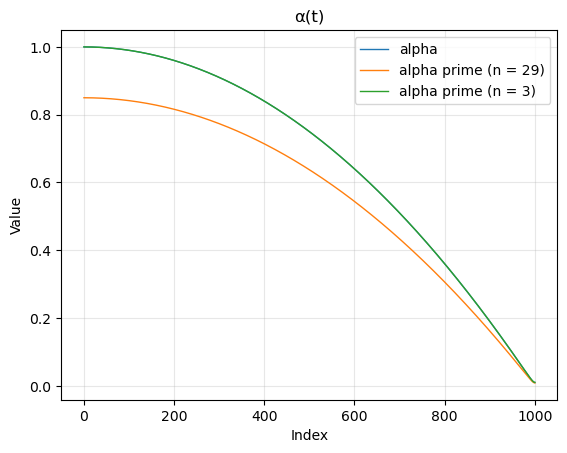

In [7]:
plt.figure()

plt.plot(np.sqrt(alphas2), label='alpha', linewidth=1)
alphas2_prime = compute_noise_parameters(29.0)["alphas2_prime"]
plt.plot(np.sqrt(alphas2_prime), label='alpha prime (n = 29)', linewidth=1)
alphas2_prime = compute_noise_parameters(3.0)["alphas2_prime"]
plt.plot(np.sqrt(alphas2_prime), label='alpha prime (n = 3)', linewidth=1)

plt.title("α(t)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

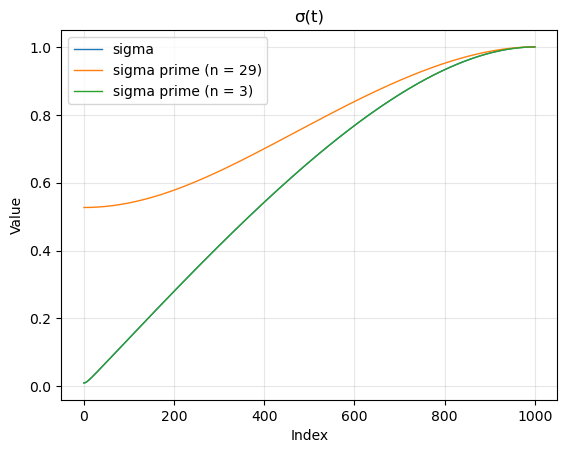

In [8]:
plt.figure()

plt.plot(np.sqrt(sigmas2), label='sigma', linewidth=1)
sigmas2_prime = compute_noise_parameters(29.0)["sigmas2_prime"]
plt.plot(np.sqrt(sigmas2_prime), label='sigma prime (n = 29)', linewidth=1)
sigmas2_prime = compute_noise_parameters(3.0)["sigmas2_prime"]
plt.plot(np.sqrt(sigmas2_prime), label='sigma prime (n = 3)', linewidth=1)

plt.title("σ(t)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

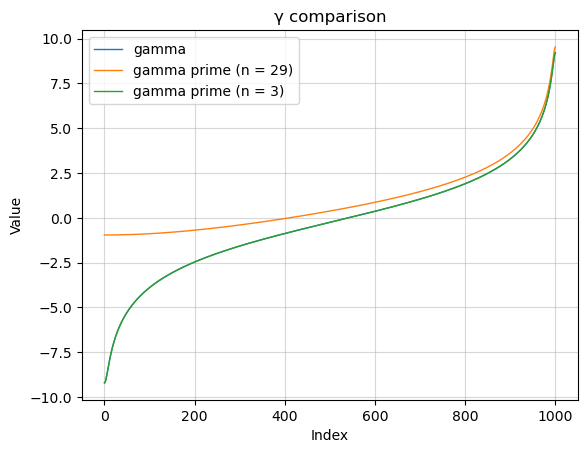

In [9]:
plt.figure()

plt.plot(gammas, label='gamma', linewidth=1)

gammas_prime = compute_noise_parameters(29.0)["gammas_prime"]
plt.plot(gammas_prime, label='gamma prime (n = 29)', linewidth=1)

gammas_prime = compute_noise_parameters(3.0)["gammas_prime"]
plt.plot(gammas_prime, label='gamma prime (n = 3)', linewidth=1)

plt.title("γ comparison")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [ ]:
git config --global user.email "st186538@stud.uni-stuttgart.de"
